## Revenue identity: R = B × OPB × AOV

For country `c`, year `t`:

$$
R_{ct} = B_{ct} \times \text{OPB}_{ct} \times \text{AOV}_{ct}
$$

- **B** = buyers, **OPB** = orders per buyer, **AOV** = average order value, **R** = revenue
- Holds by definition — a standard multiplicative accounting identity, not an assumption.

**Log form** (turns the product into a sum):

$$
\log R_{ct} = \log B_{ct} + \log \text{OPB}_{ct} + \log \text{AOV}_{ct}
$$

Useful for Bayesian modeling: each log-component can be modeled as its own
hierarchical Normal variable, summed to get `log R`, then exponentiated to
recover revenue (guaranteeing it stays positive).

In [1]:
import logging
logging.getLogger("pytensor.configdefaults").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pymc as pm  # this is for NUTS
import arviz as az # diagnostics: R-hat, divergence, az.summary()
from scipy.stats import norm 

##  Case Study Q1: three steps to a prior, then the data

**Market chosen:** Moldova

**Why:** Small e-commerce market with very limited direct data — a realistic
"data-poor" case where the hierarchical model needs to lean on structure
(covariate bridge + peer group) rather than its own observations.

**Peer group (similar GDP per capita, transition economies):**
- Albania
- Georgia
- Armenia

1. **Covariate bridge:** learn how OPB depends on GDP from countries with known OPB, then predict Moldova's OPB from its GDP.
2. **Peer adjustment:** shift that prediction by how far Moldova's peers sit from the bridge.
3. **Moldova's own data:** combine the prior with Moldova's observations (Bayes update) to get the posterior.

Everything is on the **log scale**: OPB must stay positive, and the revenue identity is multiplicative (log R = log B + log OPB + log AOV).


In [2]:
# Countries with known OPB (toy values) and their GDP per capita (USD)
known_countries = ["Ukraine", "Albania", "Georgia", "Armenia", "Serbia", "Bulgaria", "Romania"]
known_gdp = np.array([5000, 6878, 6877, 8556, 9500, 14000, 17000])
known_opb = np.array([1.6, 1.8, 2.1, 1.9, 2.4, 2.9, 3.2])

# Moldova's peer group, and their positions in the arrays above
peers = ["Albania", "Georgia", "Armenia"]
peer_idx = [known_countries.index(c) for c in peers]

# Moldova: GDP is known, OPB is almost unknown (one weak observation)
moldova_gdp = 6732
moldova_obs = np.log(np.array([2.4]))   # log scale
obs_noise_sd = 0.3                      # noise of one observation (log scale, ~30%)


**Precision** = how much we trust a source of information = 1 / variance.

$$
\tau_{\text{prior}} = \frac{1}{\sigma_{\text{prior}}^2}
$$

$$
\tau_{\text{obs}} = \frac{n}{\sigma_{\text{obs}}^2}
$$

- $\sigma_{\text{prior}}$ = uncertainty of the prior (small → high trust)
- $\sigma_{\text{obs}}$ = noise of a single observation (small → high trust)
- $n$ = number of observations (each one adds $1/\sigma_{\text{obs}}^2$ of trust, so more data → higher trust)


In [3]:
def bayesian_update_with_normal_prior(prior_mean, prior_sd, observations, obs_noise_sd):
    # prior_mean, prior_sd  = my belief before seeing any data (prior)
    # observations          = the data I actually observed
    # obs_noise_sd          = how noisy / unreliable each observation is


    prior_precision = 1 / prior_sd**2           # how much I trust the prior (small sd = high trust)
    obs_precision = len(observations) / obs_noise_sd**2  # how much I trust the data (more data = high trust)

    post_precision = prior_precision + obs_precision    # total trust = sum of both

    obs_mean = observations.mean()
    post_mean = (prior_mean*prior_precision + obs_mean*obs_precision) / post_precision
    # ^ weighted average: whichever I trust more dominates the result

    post_sd = np.sqrt(1 / post_precision)   # more trust -> less uncertainty (smaller sd)
    return post_mean, post_sd

In [4]:
# Step 1: covariate bridge (GDP -> OPB), learned from countries with known OPB

# Work on the log scale: x = log(GDP), y = log(OPB)
log_gdp = np.log(known_gdp)
log_opb = np.log(known_opb)

# Slope: how much log(OPB) moves when log(GDP) moves (co-movement / spread of x) 
slope = np.sum((log_gdp - log_gdp.mean()) * (log_opb - log_opb.mean())) / np.sum((log_gdp - log_gdp.mean())**2) # Ordinary Least Squares

# Intercept: forces the line through (mean x, mean y) where b = y_bar - m * x_bar
intercept = log_opb.mean() - slope * log_gdp.mean() 

def bridge_line(gdp):
    # Bridge prediction of log(OPB) for a given GDP
    return intercept + slope * np.log(gdp) # Basic slope equation y = m(slope)*x(log_gpd(income)) + b(intercept)

residuals = log_opb - bridge_line(known_gdp)  # Each country's distance from the line = what GDP alone cannot explain

bridge_mean = bridge_line(moldova_gdp)

# Unbiased residual standard error: sqrt(RSS / (N - 2)), mathematically cleaner than residuals.std(ddof=2)
bridge_sd = np.sqrt(np.sum(residuals**2) / (len(residuals) - 2))
#bridge_sd = residuals.std(ddof=2)   # NumPy shortcut equivalent, spread around the line (ddof=2: we fitted 2 parameters)

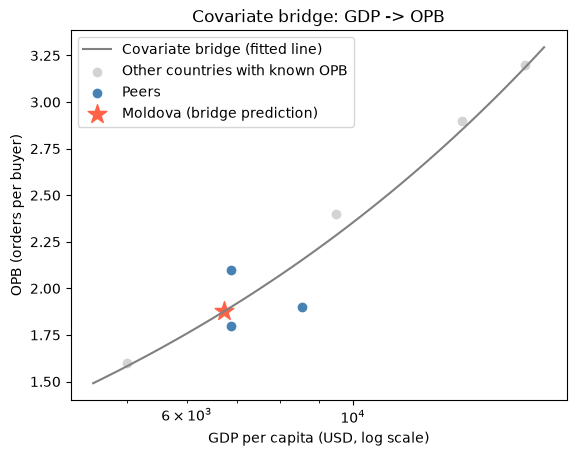

In [5]:
# The bridge: a fitted line through countries with known OPB
gdp_grid = np.linspace(4500, 18000, 100)
plt.plot(gdp_grid, np.exp(bridge_line(gdp_grid)), #np.exp(bridge_line(gdp_grid)) = np.exp(intercept + slope * np.log(gdp_grid))
         color="gray", label="Covariate bridge (fitted line)")

# Countries with known OPB: peers in blue, the rest in gray
is_peer = np.isin(known_countries, peers)
plt.scatter(known_gdp[~is_peer], known_opb[~is_peer], color="lightgray", label="Other countries with known OPB")
plt.scatter(known_gdp[is_peer], known_opb[is_peer], color="steelblue", label="Peers")

# Moldova: its GDP is known, its OPB comes from the line
plt.scatter(moldova_gdp, np.exp(bridge_mean), color="tomato", marker="*", s=200, label="Moldova (bridge prediction)")

plt.xscale("log")
plt.xlabel("GDP per capita (USD, log scale)")
plt.ylabel("OPB (orders per buyer)")
plt.title("Covariate bridge: GDP -> OPB")
plt.legend()
plt.show()


**Takeaways from the Bridge:**
* **Income Trend:** The fitted line captures the macro relationship between GDP and order frequency.
* **Moldova Baseline:** At ~6,732 USD GDP, the bridge anchors Moldova's expectation at ~1.88 OPB (red star).
* **Peer Residuals:** Regional peers (blue dots) deviate from this trend, providing the offset to adjust Moldova's prior before factoring in its own data.

In [6]:
# Step 2: peer adjustment

# How far do Moldova's peers sit from the line?
peer_residuals = residuals[peer_idx]

# Shift the bridge prediction by the average peer deviation
peer_mean = bridge_mean + peer_residuals.mean()
peer_sd = peer_residuals.std(ddof=1)   # spread among the peers

In [7]:
# Step 3: update each prior with Moldova's own data, and compare

def opb_summary(mean, sd):
    # 1.96: standard normal multiplier (log values are Gaussian, where mean ± 1.96*sd holds 95% probability)
    # np.exp: inverts the log transform to present results in real order units
    return f"{np.exp(mean):.2f} [{np.exp(mean - 1.96*sd):.2f}, {np.exp(mean + 1.96*sd):.2f}]"

# Naive baseline: plain average of the peers' OPB, no GDP bridge
peer_log_opb = log_opb[peer_idx]

priors = {
    "Peer average (naive)": (peer_log_opb.mean(), peer_log_opb.std(ddof=1)),
    "Bridge only":          (bridge_mean, bridge_sd),
    "Bridge + peers":       (peer_mean, peer_sd),
}

# Update each prior with Moldova's observation
posteriors = {name: bayesian_update_with_normal_prior(mean, sd, moldova_obs, obs_noise_sd)
              for name, (mean, sd) in priors.items()}


print(f"Moldova observation (noisy data): {np.exp(moldova_obs[0]):.2f}\n")

print(f"{'':22s}{'Prior':20s}Posterior")
for name in priors:
    print(f"{name:22s}{opb_summary(*priors[name]):20s}{opb_summary(*posteriors[name])}")

# The main result (bridge + peers) is kept for later cells
scarce_mean, scarce_sd = posteriors["Bridge + peers"]


Moldova observation (noisy data): 2.40

                      Prior               Posterior
Peer average (naive)  1.93 [1.66, 2.25]   1.96 [1.69, 2.27]
Bridge only           1.88 [1.61, 2.19]   1.91 [1.64, 2.22]
Bridge + peers        1.83 [1.46, 2.29]   1.89 [1.53, 2.34]


**Observation:** with one weak observation (2.4), the posterior (~1.89) stays close to the prior (~1.83): one noisy point cannot outweigh a prior built from the bridge and the peers.

**Revenue = Buyers × OPB × AOV**

In [8]:
# Rich data: 100 simulated observations of Moldova's OPB (true value 2.4), log scale
rich_obs = np.random.default_rng(0).normal(np.log(2.4), obs_noise_sd, size=100)
rich_mean, rich_sd = bayesian_update_with_normal_prior(peer_mean, peer_sd, rich_obs, obs_noise_sd)

print(f"Scarce data (1 obs):  {opb_summary(scarce_mean, scarce_sd)}")
print(f"Rich data (100 obs):  {opb_summary(rich_mean, rich_sd)}")


Scarce data (1 obs):  1.89 [1.53, 2.34]
Rich data (100 obs):  2.41 [2.28, 2.55]


## Key Takeaways

* **Partial Pooling in Action:** With scarce data, Moldova doesn't stand alone; the model blends its weak data with regional peers to avoid overfitting.
* **Data Volume Dictates Trust:** As data grows, the model naturally shifts reliance from regional priors to Moldova's own numbers, tightening the confidence interval.
* **A Reusable Template:** This same logic (macro bridge + peer offsets) applies to **Buyers** (via population) and **AOV** (via price index). A full hierarchical model does this weighting automatically across all markets.
* **Toy Setup:** Simplified with 7 countries and fixed noise; production models learn these variance parameters jointly across all regions.

# Case Study Q2: A new data source arrives

A new source gives observed OPB for 20 countries (2022–2024), of varying quality, including Moldova's peers.

- **Years (2022–2024):** treated here as repeated observations per country. In the full model I would add a year effect (or a smooth trend) so that a rising OPB is not mistaken for country differences.
- **Where it enters:** as likelihood data for each country's latent OPB. The peers now have real observations instead of assumptions.
- **What changes for OPB:** the peer offset is recomputed from the data-backed peer estimates, weighted by data quality (noisy peers count less). Moldova gets no new data, but its prior moves.
- **What changes for revenue:** only the log OPB term of log R = log B + log OPB + log AOV shifts. B and AOV stay the same.
- **Simplification:** here only the peers are simulated and the bridge stays fixed. In the full model all 20 countries also refit the bridge itself, and source quality is learned rather than assumed.


In [9]:
rng = np.random.default_rng(1)

# True OPB per peer (unknown in reality, only used to simulate the new data)
true_opb = {"Albania": 1.85, "Georgia": 2.05, "Armenia": 1.95}

# "Varying quality" -> different noise per country (log scale). Georgia = noisiest
noise_by_country = {"Albania": 0.25, "Georgia": 0.45, "Armenia": 0.15}
number_obs_by_country = {"Albania": 15, "Georgia": 8, "Armenia": 20}

new_peer_data = {c: rng.normal(np.log(true_opb[c]), noise_by_country[c], size=number_obs_by_country[c])
                 for c in peers}


In [10]:
# Step 1 (Q2): broad starting belief per peer (log scale), then update with its new data
weak_prior_mean, weak_prior_sd = np.log(2.0), 0.5

peer_est = {}   # country -> (log mean, log sd)
for c in peers:
    peer_est[c] = bayesian_update_with_normal_prior(weak_prior_mean, weak_prior_sd,
                                                    new_peer_data[c], noise_by_country[c])
    print(f"{c}: n={number_obs_by_country[c]}, OPB {opb_summary(*peer_est[c])}")


Albania: n=15, OPB 1.90 [1.67, 2.15]
Georgia: n=8, OPB 2.08 [1.55, 2.80]
Armenia: n=20, OPB 1.90 [1.78, 2.03]


In [11]:
# Step 2 (Q2): each peer's distance from the bridge line, now from its data-backed estimate
est_mean = np.array([peer_est[c][0] for c in peers])
est_sd = np.array([peer_est[c][1] for c in peers])
new_resid = est_mean - bridge_line(known_gdp[peer_idx])

# Weight peers by precision: noisier peers (bigger sd) count less
weights = 1 / est_sd**2
share = weights / weights.sum()
print({c: round(float(w), 2) for c, w in zip(peers, share)})   # Georgia gets the least

new_offset = np.sum(weights * new_resid) / np.sum(weights)
new_prior_mean = bridge_mean + new_offset
new_prior_sd = new_resid.std(ddof=1)


{'Albania': 0.21, 'Georgia': 0.04, 'Armenia': 0.76}


In [12]:
# Step 3 (Q2): Moldova's posterior before vs after
new_mean, new_sd = bayesian_update_with_normal_prior(new_prior_mean, new_prior_sd, moldova_obs, obs_noise_sd)

print(f"BEFORE new source: {opb_summary(scarce_mean, scarce_sd)}")
print(f"AFTER  new source: {opb_summary(new_mean, new_sd)}")

# R = B x OPB x AOV: with B and AOV fixed, R moves by the same factor as OPB
print(f"Revenue change (B, AOV fixed): {np.exp(new_mean - scarce_mean) - 1:+.1%}")


BEFORE new source: 1.89 [1.53, 2.34]
AFTER  new source: 1.78 [1.46, 2.18]
Revenue change (B, AOV fixed): -6.0%


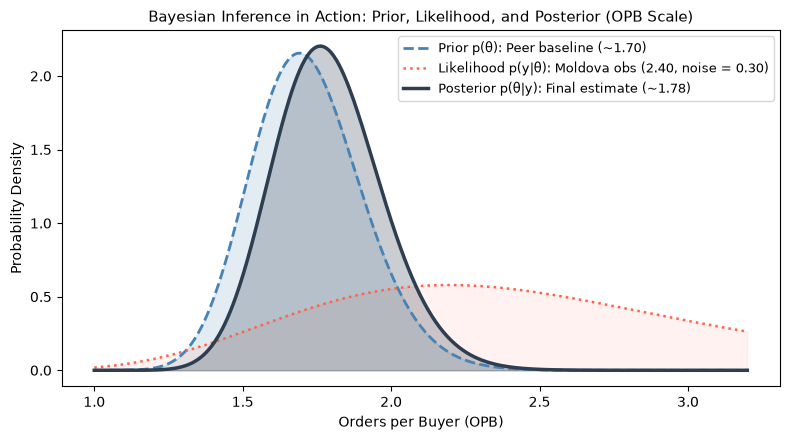

In [13]:
# 1. Define OPB domain (natural orders scale)
x = np.linspace(1.0, 3.2, 500)

# 2. Probability densities
prior_density = norm.pdf(np.log(x), loc=new_prior_mean, scale=new_prior_sd) / x
likelihood_density = norm.pdf(np.log(x), loc=moldova_obs[0], scale=obs_noise_sd) / x
post_density = norm.pdf(np.log(x), loc=new_mean, scale=new_sd) / x

# 3. Plotting with matching visual palette (matching Bridge plot)
plt.figure(figsize=(8, 4.5))

plt.plot(
    x,
    prior_density,
    label="Prior p(θ): Peer baseline (~1.70)",
    color="steelblue",
    linewidth=2,
    linestyle="--",
)
plt.fill_between(x, prior_density, color="steelblue", alpha=0.15)

plt.plot(
    x,
    likelihood_density,
    label="Likelihood p(y|θ): Moldova obs (2.40, noise = 0.30)",
    color="tomato",
    linewidth=1.8,
    linestyle=":",
)
plt.fill_between(x, likelihood_density, color="tomato", alpha=0.08)

plt.plot(
    x,
    post_density,
    label="Posterior p(θ|y): Final estimate (~1.78)",
    color="#2c3e50",
    linewidth=2.5,
)
plt.fill_between(x, post_density, color="#2c3e50", alpha=0.25)

plt.title("Bayesian Inference in Action: Prior, Likelihood, and Posterior (OPB Scale)", fontsize=11)
plt.xlabel("Orders per Buyer (OPB)", fontsize=10)
plt.ylabel("Probability Density", fontsize=10)
plt.legend(frameon=True, fontsize=9)
plt.tight_layout()
plt.show()

**Interpretation of the Bayesian Update:**
- **Prior vs. Likelihood Tension:** The peer-backed prior ($~1.70$) is narrow and confident, while the single local observation ($2.40$) represented by the likelihood is wide and uncertain due to high noise ($\sigma = 0.30$).
- **Dominance of Quality-Weighted Peers:** Because the prior carries significantly more precision than a single noisy data point, it heavily anchors the belief and pulls the estimate strongly to the left.
- **Robustness Against Outliers:** The posterior ($~1.78$) only shifts marginally toward the data, preventing the business model from overreacting to the $2.40$ outlier and yielding a well-regularized -6.0% revenue adjustment.

## Checks before trusting the new fit

- R-hat / divergences: re-run and confirm convergence
- Posterior predictive check: simulate from the updated model, compare to new data
- Check that lower-quality countries (e.g. Georgia, noisier) get less weight
- Leave-one-country-out on the new 20 countries
- Sensitivity: refit without the new source and compare, to spot a biased source


# Case Study Q3: The re-fit goes wrong

After adding the new source + a group of new countries, the re-fit shows:
- R-hat ≈ 1.12 on several country effects
- ~40 divergences

**Task:** hypotheses (in order to test), what to change in model/sampler,
and which earlier numbers (from Q1, Q2) to stop reporting until resolved.

## Hypotheses, in testing order

| # | Hypothesis | Test → change |
|---|---|---|
| 0 | *(free)* Where is the problem? | Which parameters have R-hat > 1.01, do divergences cluster on the new countries? (pair plot `group_sd` vs country effect) |
| 1 | New country effects are centered and data-poor (funnel) | Divergences at small `group_sd`? → non-centered for the new effects |
| 2 | One shared noise for sources of very different quality | Compare shared vs per-source `obs_sd` → per-source noise (Student-t if outliers) |
| 3 | New source and new countries are confounded | Refit without the source → source-bias term, sum-to-zero |
| 4 | Prior conflicts with the data | Prior predictive check → wider or heavier-tailed prior |
| 5 | Sampler settings | Rerun with `target_accept` 0.95–0.99, more `tune` |

**Order:** free diagnostics first, then the cheapest and most likely cause (new countries have little data, which is the funnel setup). The sampler is last: it only relieves the symptom and can hide a real model problem.

**Stop reporting until R-hat < 1.01 and no divergences:** everything that comes from the re-fit, i.e. Moldova's updated OPB and interval and the revenue change (Q2), and Moldova's posterior (Q1) since it shares the bridge and hierarchy. Intervals for data-poor markets like Moldova go first, because divergences make uncertainty too small exactly there.


### Hypothesis 1: Centered vs. Non-Centered (Neal's Funnel)

* **Sampler Context:** NUTS is an extension of **Hamiltonian Monte Carlo (HMC)** that simulates physical trajectories along the posterior surface using leapfrog integration.
* **The Pathology:** In data-poor groups, as `group_sd -> 0`, the geometry forms an extremely narrow "funnel". HMC's numerical integrator cannot handle this high curvature, causing trajectory breakdowns (**divergences**) and chain disagreement ($\hat{R} > 1.01$).
* **The Fix (Non-Centered):** Reparameterizing via $z \sim \mathcal{N}(0, 1)$ with $\theta = \mu + \sigma \cdot z$ decouples the group means from $\sigma$. This flattens the funnel into an isotropic Gaussian cloud, allowing NUTS to traverse the space smoothly without getting trapped.
* **Rule:** Fix the geometry first (non-centering); only increase `target_accept` as a final touch for minor numerical residual noise.

In [14]:
# 10 groups, very uneven sizes, nearly identical true means (small true group_sd)
rng = np.random.default_rng(7)
funnel_sizes = np.array([2, 3, 5, 8, 15, 25, 50, 80, 120, 200])
funnel_true_means = rng.normal(5.0, 0.1, size=10)

funnel_idx, funnel_y = [], []
for g in range(10):
    funnel_y.extend(rng.normal(funnel_true_means[g], 3.0, size=funnel_sizes[g]))
    funnel_idx.extend([g] * funnel_sizes[g])
funnel_y, funnel_idx = np.array(funnel_y), np.array(funnel_idx)


In [15]:
def fit_funnel_model(centered: bool, target_accept: float):
    """
    Simulates Neal's Funnel pathology to test Hypothesis 1 using NUTS (an HMC extension).

    The algorithm moves like a skateboarder in a bowl. 

    In the centered model, low group variance creates a sharp, narrow 'funnel' 
    where the sampler crashes into walls (divergences) and fails to explore (R-hat > 1.01). 
    Non-centering flattens the bowl so it can move smoothly without crashing.

    Parameters:
    - centered: True for centered form (causes funnel), False for non-centered 
      z ~ N(0, 1) form (flattens geometry into an easy-to-sample Gaussian cloud).
    - target_accept: Target acceptance rate to fine-tune NUTS step size.

    Returns:
    - n_div: Number of divergent transitions (target: 0).
    - r_hat: Maximum Gelman-Rubin convergence metric (target: <= 1.01).
    - trace: MCMC posterior draws and sample statistics.
    """
    
    with pm.Model():
        global_mean = pm.Normal("global_mean", 0, 10)
        group_sd = pm.HalfNormal("group_sd", 1)
        if centered:
            group_mean = pm.Normal("group_mean", mu=global_mean, sigma=group_sd, shape=10)
        else:
            z = pm.Normal("z", 0, 1, shape=10)   # non-centered: z is standard normal
            group_mean = pm.Deterministic("group_mean", global_mean + group_sd * z)
        obs_sd = pm.HalfNormal("obs_sd", 5)
        pm.Normal("y_obs", mu=group_mean[funnel_idx], sigma=obs_sd, observed=funnel_y)
        trace = pm.sample(2000, tune=1000, chains=4, target_accept=target_accept,
                          random_seed=7, cores=1, progressbar=False)   # this one is working with model NUTS 

    n_div = int(trace.sample_stats["diverging"].sum())
    r_hat = float(az.rhat(trace, var_names=["group_mean"])["group_mean"].max())
    return n_div, round(r_hat, 3), trace

In [16]:
# Same data, three setups
rows = []      # one result row per setup (for the table)
traces = {}    # the full fitted traces (for the funnel plot)
for name, centered, target_accept in [("Centered", True, 0.9),
                                      ("Non-centered", False, 0.9),
                                      ("Non-centered", False, 0.99)]:
    n_div, r_hat, trace = fit_funnel_model(centered, target_accept)
    traces[(name, target_accept)] = trace
    rows.append({"model": name, "target_accept": target_accept, "divergences": n_div, "max R-hat": r_hat})
print(pd.DataFrame(rows))


Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, group_mean, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 9 seconds.
There were 267 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, z, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 7 seconds.
There were 6 divergences after tuning. Increase `target_accept` or reparameterize.
Initializing NUTS using

          model  target_accept  divergences  max R-hat
0      Centered           0.90          267      1.031
1  Non-centered           0.90            6      1.001
2  Non-centered           0.99            0      1.001


**Reading it:** centered gives many divergences, non-centered removes most of them, and a higher `target_accept` cleans up the rest. Reparameterizing fixes the cause, `target_accept` only relieves the symptom, so it comes last.

The demo reproduces the mechanism (funnel, divergences, fix), not the exact size of the problem: here max R-hat is about 1.03 instead of 1.12. The real re-fit has more countries, a shared noise term and a source effect on top.


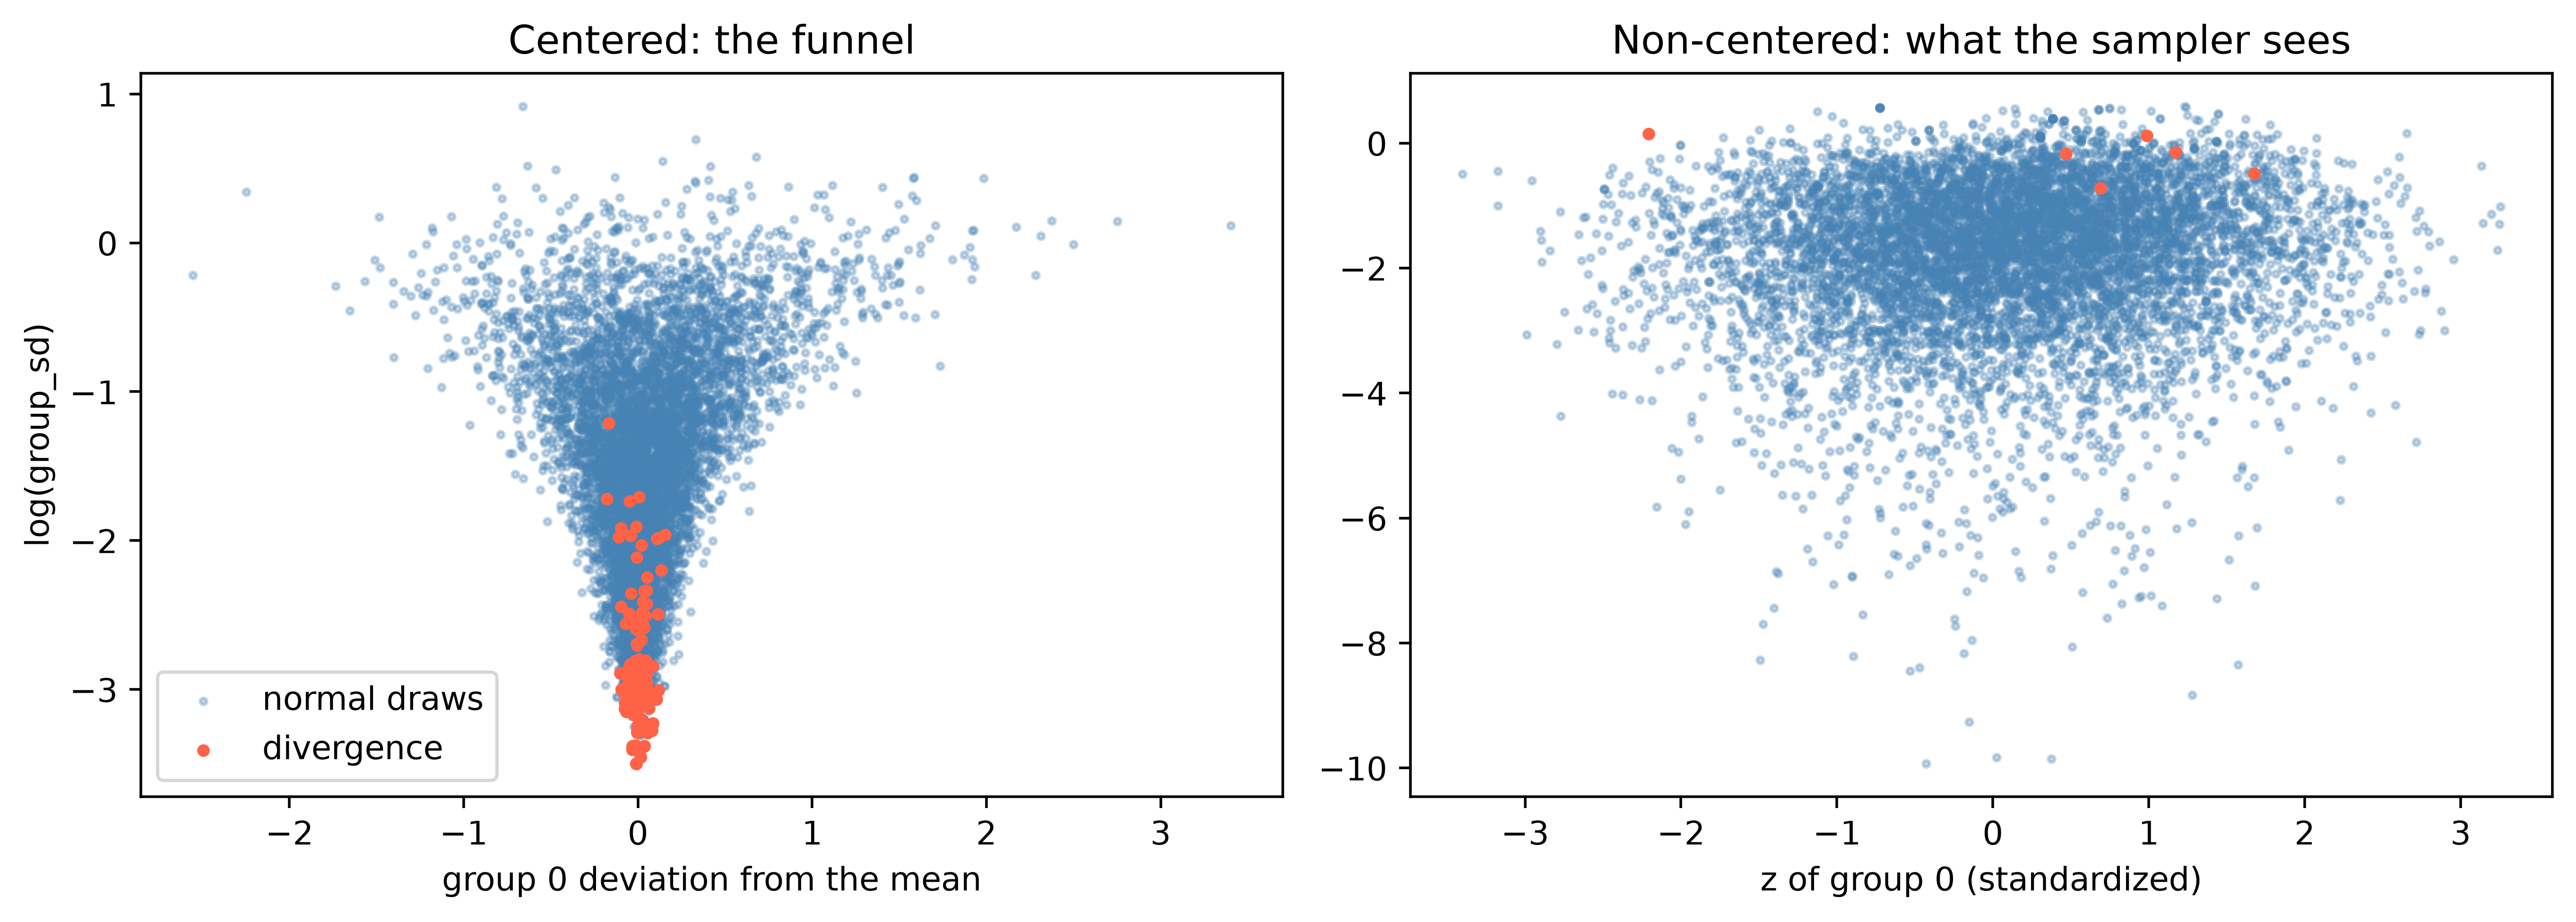

In [17]:
def funnel_coords(trace, centered):
    # y: log of group_sd; x: deviation of the smallest group (n=2) from the overall mean
    log_sd = np.log(trace.posterior["group_sd"].values.ravel())
    if centered:
        x = (trace.posterior["group_mean"].values[..., 0] - trace.posterior["global_mean"].values).ravel()
    else:
        x = trace.posterior["z"].values[..., 0].ravel()   # standardized deviation
    diverging = trace.sample_stats["diverging"].values.ravel()
    return x, log_sd, diverging

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=False, dpi=500)
for ax, key, centered, title in [
    (axes[0], ("Centered", 0.9), True, "Centered: the funnel"),
    (axes[1], ("Non-centered", 0.9), False, "Non-centered: what the sampler sees"),
]:
    x, log_sd, diverging = funnel_coords(traces[key], centered)
    ax.scatter(x[~diverging], log_sd[~diverging], s=4, alpha=0.3, color="steelblue", label="normal draws")
    ax.scatter(x[diverging], log_sd[diverging], s=8, color="tomato", label="divergence")
    ax.set_title(title)
    ax.set_xlabel("group 0 deviation from the mean" if centered else "z of group 0 (standardized)")
axes[0].set_ylabel("log(group_sd)")
axes[0].legend()
plt.tight_layout()
plt.show()


### Summary: Why the Model Failed and How We Fixed It

* **Convergence (R-hat):**
  * Tells us if the chains found the same solution.
  * We want **R-hat <= 1.01**. A value like **1.12** means the chains are lost and disagree.

* **Divergence:**
  * A warning that the sampler got stuck in a sharp corner and the math broke down.
  * In a good model, this should be **0**.

* **The Funnel Problem (Left Plot):**
  * When countries have very little data, the model creates a sharp, narrow "funnel" shape.
  * The sampler cannot fit through this narrow neck and crashes (shown by the red dots).

* **The Fix: Non-centered (Right Plot):**
  * By standardizing the variables (`z = Normal(0, 1)`), we flatten the funnel into an open, round cloud.
  * The sampler moves smoothly, divergences drop to zero, and the chains converge.

##Takeaway & Operational Action Plan

* **Most Likely Explanation:** The re-fit failure (40 divergences, $\hat{R} \approx 1.12$) was driven by Neal's Funnel pathology in data-poor countries under centered parameterization.
* **Resolution Path:** 
  1. Transition the production hierarchical engine from centered to **non-centered parameterization**.
  2. Increase `target_accept` to **0.99** to eliminate residual boundary noise.
* **What I would do:** 
  Reporting for Moldova's updated OPB ($1.78$) and the projected **-6.0% revenue adjustment** remains strictly halted until the non-centered re-fit achieves $\hat{R} \le 1.01$ and $0$ divergences.

# Case Study Q4: Minimal Hierarchical Model with NUTS

Build a small hierarchical model with ~10 groups of very uneven sample
sizes and fit it with NUTS.

Same structure as the Q3 demo (10 groups, n from 2 to 200, non-centered parameterization), but with groups that genuinely differ from each other.


In [18]:
rng = np.random.default_rng(42)

group_sizes = np.array([2, 3, 5, 8, 15, 25, 50, 80, 120, 200])
n_groups = len(group_sizes)

true_group_means = rng.normal(5.0, 2.0, size=n_groups)

group_idx, y = [], []
for g in range(n_groups):
    obs = rng.normal(true_group_means[g], 3.0, size=group_sizes[g])
    y.extend(obs)
    group_idx.extend([g] * group_sizes[g])
y, group_idx = np.array(y), np.array(group_idx)


In [19]:
with pm.Model() as q4_model:
    global_mean = pm.Normal("global_mean", 0, 10)      # overall average across groups
    group_sd = pm.HalfNormal("group_sd", 5)            # how much groups differ from each other
    z = pm.Normal("z", 0, 1, shape=n_groups)           # standardized group deviations (non-centered)
    group_mean = pm.Deterministic("group_mean", global_mean + group_sd * z)   # each group's mean
    obs_sd = pm.HalfNormal("obs_sd", 5)                # noise within a group
    pm.Normal("y_obs", mu=group_mean[group_idx], sigma=obs_sd, observed=y)   # likelihood


    trace_q4 = pm.sample(2000, tune=1000, chains=4, target_accept=0.95,
                          random_seed=42, cores=1, progressbar=False)

print(az.summary(trace_q4, var_names=["global_mean", "group_sd", "obs_sd"]))
n_div = int(trace_q4.sample_stats["diverging"].sum())
print(f"\nDivergences: {n_div}")

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [global_mean, group_sd, z, obs_sd]
Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 12 seconds.


              mean     sd eti89_lb eti89_ub ess_bulk ess_tail r_hat mcse_mean mcse_sd
global_mean   4.38   0.66      3.4      5.4     1587     2096  1.00     0.017   0.014
group_sd      1.75   0.64     0.92      2.9     1892     3200  1.00     0.014  0.0099
obs_sd       2.927  0.095      2.8      3.1     7564     5617  1.00    0.0011  0.0011

Divergences: 0


## Shrinkage: naive vs. posterior means

Small groups are pulled toward the overall mean (group 0, n=2: naive 8.10 → posterior about 5.9), while large groups barely move (group 9, n=200: 3.26 → 3.28). This is partial pooling: each group borrows strength from the others in proportion to how little data it has.


In [20]:
posterior_means = trace_q4.posterior["group_mean"].mean(dim=["chain", "draw"]).values
for g in range(n_groups):
    naive = y[group_idx == g].mean()
    print(f"group {g} (n={group_sizes[g]:3d}): naive={naive:6.2f}  posterior={posterior_means[g]:6.2f}")

group 0 (n=  2): naive=  8.10  posterior=  5.87
group 1 (n=  3): naive=  4.58  posterior=  4.47
group 2 (n=  5): naive=  6.13  posterior=  5.43
group 3 (n=  8): naive=  7.00  posterior=  6.20
group 4 (n= 15): naive=  1.60  posterior=  2.14
group 5 (n= 25): naive=  2.54  posterior=  2.78
group 6 (n= 50): naive=  4.54  posterior=  4.53
group 7 (n= 80): naive=  4.47  posterior=  4.46
group 8 (n=120): naive=  4.97  posterior=  4.95
group 9 (n=200): naive=  3.26  posterior=  3.28


## Summary & Key Findings

1. **Partial Pooling under Data Scarcity (Q1 & Q4):**  
   The model effectively borrows strength from peers via the covariate bridge when country-level data is sparse. In our minimal PyMC model, a small group ($n=2$) is shrunk significantly toward the global mean (from raw 8.10 to posterior ~5.87), while data-rich groups ($n=200$) remain virtually unshifted, preserving genuine signals.

2. **Propagation of New Evidence (Q2):**  
   Integrating incoming OPB data directly as a likelihood updates the peer distribution. Because the peers are weighted by their observation noise (precision), high-noise countries contribute less pull. This update propagates cleanly through the multiplicative accounting identity ($\log R = \log B + \log \text{OPB} + \log \text{AOV}$), shifting Moldova's latent OPB and its resulting revenue estimate accordingly.

3. **Resolving Sampler Geometries (Q3):**  
   MCMC convergence diagnostics ($R\text{-hat} \approx 1.12$, ~40 divergences) on sparse groups are classic symptoms of Neal's Funnel. The root mathematical fix is transitioning to a **non-centered parameterization** ($\theta = \mu + \sigma z$). As demonstrated, this flattens the funnel geometry, eliminating divergences before relying on empirical tuning adjustments like `target_accept`.

4. **Production Safeguard:**  
   In a production reporting setup, whenever $R\text{-hat} > 1.01$ or divergences occur, updated estimates and credible intervals for data-poor markets must be withheld, as funnel pathologies artificially compress posterior uncertainty precisely where it should remain wide.